# Plotting the stars of galaxy Storm 2 color-coded by progenitor and their mass-weighted ages and metallicities

#### This code can be modified to analyze the stars of any galaxy by being given the appropriate snapshot and h5py file. Efficiency depends on the amount of stars in the galaxy.

###### Credit: Parts of the code for the progenitor plotting were copied from "plothalomergersMM.py" by Nithun Selva, an algorithm that animates the evolution of a merging galaxy. Then we modified the code itself and its documentation to fit our purposes.

In [2]:
# Import all necessary libraries
import pynbody
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pynbody.array import SimArray
import tqdm.auto as tqdm

s = pynbody.load('/home/christenc/Storage/Cosmo/storm.cosmo25cmb/storm.cosmo25cmb.4096g5HbwK1BH/storm.cosmo25cmb.4096g5HbwK1BH.004096/storm.cosmo25cmb.4096g5HbwK1BH.004096')

h = s.halos(halo_numbers='v1')  # Load the halos using the original AHF numbering system
h.load_all()
unique_halo_ids = list(h.keys())

num = 2 
main_halo = h[num]

pynbody.analysis.halo.center
cen = main_halo.mean_by_mass('pos')

sp = s[pynbody.filt.Sphere(SimArray([200], "kpc"), cen)].load_copy()

s.physical_units()

In [3]:
# Import all the host IDs, particle IDs and their associated information from the h5py file
with h5py.File('/home/christenc/Storage/Cosmo/storm.cosmo25cmb/storm.cosmo25cmb.4096g5HbwK1BH/storm.cosmo25cmb.4096g5HbwK1BH_allhalostardata_upd.h5','r') as f:
    hostids = f['host_IDs'].asstr()[:]  # host IDs
    partids = f['particle_IDs'][:]  # particle IDs
    pct = f['particle_creation_times'][:]  # formation times
    ph = f['particle_hosts'][:]  # local host IDs (i.e., host at formation time)
    pp = f['particle_positions'][:]  # position at formation time
    tsloc = f['timestep_location'][:]  # snapshot where star particle first appears

# Map particle IDs to their host ID (from the h5py file)
halo_particle_dict = {}

for i, part in enumerate(partids):
    halo_particle_dict[part] = hostids[i]

# Map ages to their unique particle ID (from the h5py file)
age_particle_dict = {}

for i, part in enumerate(partids):
    age_particle_dict[part] = pct[i]

# Map metallicities to their unique particle ID (from the snapshot since they were not included in the h5py data)
metal_particle_dict = {}

for i, part in enumerate(sp.s['iord']):
    metal_particle_dict[part] = sp.s['feh'][i]

# Map masses to their unique particle ID (from the snapshot since they were not included in the h5py data)
mass_particle_dict = {}

for i, part in enumerate(sp.s['iord']):
    mass_particle_dict[part] = sp.s['mass'][i]

In [4]:
def make_colormap(unique_haloids):
    """Creates a color map for the unique halo IDs.

    Args:
        unique_haloids (array): A list of non-repeating unique halo IDs.

    Returns:
        dict: A dictionary mapping halo IDs to their corresponding colors.
    """
    
    colors = plt.get_cmap('tab20', len(unique_haloids))
    color_map = {hid: colors(i) for i, hid in enumerate(unique_haloids)}
    
    return color_map

In [5]:
def plot_halo_mergers(sp, mask, haloids, color_map, savepath=None):
    """Plots stellar positions from a simulation in three 2D projections.

    This function generates a 1x3 matplotlib figure showing XY, YZ, and XZ
    scatter plots of star particle positions. Particles are colored based on
    their unique host halo ID. The function includes an optional legend 
    (with counts from each haloid) and can save the figure to a file.

    Args:
        sp (pynbody.snapshot.SimSnap): 
            The pynbody snapshot or sub-snapshot containing the particle data.
        mask (array): 
            A boolean mask or array of indices used to select the desired 
            star particles from `sp`.
        haloids (array): 
            A list of original host halo IDs, corresponding to the particles 
            selected by `mask`.
        color_map (dict): 
            A dictionary mapping each unique halo ID from `haloids` to a 
            matplotlib color.
        savepath (str, optional): 
            The file path to save the generated plot. If None, the plot is 
            only displayed. Defaults to None.
            
    Returns:
        None
    """
    # Create an array of colors for each star particle
    particle_colors = [color_map[hid] for hid in haloids]
    # Create the scatter plot
    fig, axes = plt.subplots(1,3,figsize=(36,12))
    # Define projections
    projections = [
        {'ax': axes[0], 'dims': [0, 1], 'labels': ['x (kpc)', 'y (kpc)'], 'title': 'X-Y Projection'},
        {'ax': axes[1], 'dims': [1, 2], 'labels': ['y (kpc)', 'z (kpc)'], 'title': 'Y-Z Projection'},
        {'ax': axes[2], 'dims': [0, 2], 'labels': ['x (kpc)', 'z (kpc)'], 'title': 'X-Z Projection'}
    ]

    # Matches color to each halo 
    unique_hids = np.unique(haloids)
    pos_data = sp.s['pos'][mask]
    particle_colors_arr = np.array(particle_colors)  # (N, 4) for boolean-mask indexing

    # Creates scatter-plots
    for proj in projections:
        ax = proj['ax']
        dim1 = proj['dims'][0]
        dim2 = proj['dims'][1]

        ax.scatter(
            pos_data[:, dim1],
            pos_data[:, dim2],
            c=particle_colors,
            zorder=3,
            s=25.0,  # Marker size
            alpha=0.5,  # Use transparency to see overlapping structures
            edgecolors='none'  # Remove marker edges for a cleaner look
        )

        ax.set_title(proj['title'], fontsize=14)
        ax.set_xlabel(proj['labels'][0], fontsize=12)
        ax.set_ylabel(proj['labels'][1], fontsize=12)

    # Display the legend — include star count for each halo_id
    host_instance_dict = {}
    for i in range(len(unique_hids)):
        d = 0
        for j in range(len(haloids)):
            if haloids[j] == unique_hids[i]:
                d = d+1
        host_instance_dict.update({unique_hids[i]: d})          

    legend_patches = [
        mpatches.Patch(
            color=color_map[hid],
            label=f'{hid} (N={host_instance_dict[hid]})'
        )
        for hid in unique_hids
    ]
    if len(legend_patches) <= 40:
        axes[0].legend(handles=legend_patches, title="Original Halo ID", loc='upper right', fontsize=12)
    else:
        tqdm.tqdm.write(f"Warning: {len(legend_patches)} unique halos found. Legend will not be displayed to avoid clutter.")
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    #Saves plot if desired
    if savepath:
        tqdm.tqdm.write(f"Saving plot to {savepath}")
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

In [6]:
#Selects for star particles only found in both the snapshot and h5 file
id_intersection = np.intersect1d(sp.s['iord'], partids)
inc_mask = np.isin(sp.s['iord'], id_intersection)

#Creates array of hosts corresponding to array of particles
host_per_particle = [''] * len(id_intersection)
for i in range(len(id_intersection)):
    current_id = id_intersection[i]
    host_per_particle[i] = halo_particle_dict[current_id]

In [7]:
colormap = make_colormap(np.unique(host_per_particle)) #actually makes colormap

In [8]:
def multiple_view(host_ids, bin_number = 50, plot = True, hist = True, masses = True):

    """Plots stellar positions for any given set of progenitor halos. Also creates age and metallicity histograms.

    This function generates 3 matplotlib figures showing XY, YZ, and XZ
    scatter plots of star particle positions, as well as histograms of age and 
    metallicity. Particles are colored based on
    their unique host halo ID. The number of histogram bins can also be adjusted.

    Args:
        host_ids: 
            The set of halo_ids to be displayed. Takes array of strings.
        color_map: 
            A set of colors that will be matched to halo_ids inside the function.
            Takes (N, 4) values.
        bin_number: 
            The number of bins for the histogram.
        plot: 
            Determines whether to create plots.
        age_hist: 
            Determines whether to create an age histogram.
        metal_hist:
            Determines whether to create a metallicity histogram.
            
    Returns:
        Nothing but graphs.
    """

    #Counts the total number of particles belonging to each host_id.
    a=0
    for i in range(len(host_per_particle)):
        for j in range(len(host_ids)):
            if host_per_particle[i] == host_ids[j]:
                a = a+1

    # Initializes empty lists to be used below
    particles_by_host = [''] * (a) # Becomes list of particles ordered, but not separated, by host
    mixed_particles = [''] * (a) #Unsorted list of particles
    hosts_by_host = [''] * (a) #List of host_ids ordered, but not separated, by host. Aligns with particles_by_host
    mixed_by_host = [''] * (a) #Unsorted list of particles
    universe_age = 13.78
    b = 0
    age_groups = [] # Age of star particles, separated by host
    metallicity_groups = [] #Metallicity of star particles, separated by host
    mass_groups = [] #Mass of star particles, separated by host. 
    
    #For each host_id, checks every particle to see if ID is correct. If so, adds mass, age, and metallicity to relevant array.
    for j in range(len(host_ids)):
        current_host_age_group = [] 
        current_host_metallicity_group = []
        current_host_mass_group = []
        
        for i in range(len(id_intersection)):
            current_id = id_intersection[i]
            
            if halo_particle_dict[current_id] == host_ids[j]:
                particles_by_host[b] = current_id
                hosts_by_host[b] = halo_particle_dict[current_id]
                age = universe_age - age_particle_dict[current_id] #flipping
                metal = metal_particle_dict[current_id]
                mass = mass_particle_dict[current_id]
                
                b = b + 1
                current_host_age_group.append(age)
                current_host_metallicity_group.append(metal)
                current_host_mass_group.append(mass)

        age_groups.append(current_host_age_group)
        metallicity_groups.append(current_host_metallicity_group)
        mass_groups.append(current_host_mass_group)

    b = 0

    #Creates list of particles for only the desired hosts. Not sorted.
    for j in range(len(id_intersection)):
        current_id = id_intersection[j]

        for i in range(len(host_ids)):
            if halo_particle_dict[current_id] == host_ids[i]:
                mixed_particles[b] = current_id
                mixed_by_host[b] = halo_particle_dict[current_id]
                b = b + 1

    #Makes sure particles_by_host is of the correct length
    host_mask = np.isin(sp.s['iord'], particles_by_host)
    
    #Matche halo_ids to color from color_map function
    colormap = make_colormap(host_ids) #actually makes colormap
    particle_colors = [colormap[hid] for hid in host_ids]
    particle_colors_arr = np.array(particle_colors)


    #Optional graphing features for position, age, and metallicity respectively.
    if plot == True:
        plot_halo_mergers(sp, host_mask, mixed_by_host, colormap)
        
    if hist == True:
        
        plt.figure(figsize=(9,3.6), layout ='constrained')

        plt.subplot(1,2,1)
        plt.hist(age_groups, bins=bin_number, stacked=True, histtype='step', color=particle_colors_arr, label='Stars',
                 range=(0, universe_age), weights=mass_groups)
        plt.ylabel("Total Mass(2*10^15 Msol)")
        plt.xlabel("Age (Gyr) of Star Particles")
        plt.title("Star Particle Ages: Weighted by Mass")
        
        plt.subplot(1,2,2)
        plt.hist(metallicity_groups, bins=bin_number, stacked=True, histtype='step', color=particle_colors_arr, label='Stars',
                 range=(-4,1), weights=mass_groups)
        plt.xlabel("Metallicity (Fe/h) of Star Particles")
        plt.title("Star Particle Metallicities: Weighted by Mass")

        plt.show()

    if masses == True:
        plt.hist(mass_groups, bins=bin_number, stacked=True, histtype='step', color=particle_colors_arr, label='Stars', log=True)
        plt.ylabel("Counts")
        plt.xlabel("Mass of Star Particles (2*10^15 Msol)")
        plt.title("Histogram of Star Particle Masses")
        plt.show()
        

    return 


In [9]:
text = np.unique(hostids) #for diagnostic purposes

csv = ",".join(f'"{x}"' for x in text)

print(csv)
#This is designed to make it easy enough to copy and paste which halo_ids one wants in halo_finder 

"0000_0","0192_25","0288_95","0480_43","0480_61","0576_14","0672_27","0672_9","0864_90","0960_8","1056_27","1056_364","1344_29","1440_49","1632_6","1824_143","2304_133","2304_14","2400_28","2400_29","2688_47","2976_36","3456_270","3456_56","3552_300","3648_85","3648_90","3744_13","4032_287","4096_1","4096_10","4096_11","4096_124","4096_13","4096_14","4096_16","4096_192","4096_2","4096_20","4096_208","4096_218","4096_22","4096_23","4096_24","4096_253","4096_28","4096_292","4096_3","4096_34","4096_35","4096_39","4096_4","4096_43","4096_47","4096_49","4096_5","4096_50","4096_6","4096_60","4096_7","4096_72","4096_8"


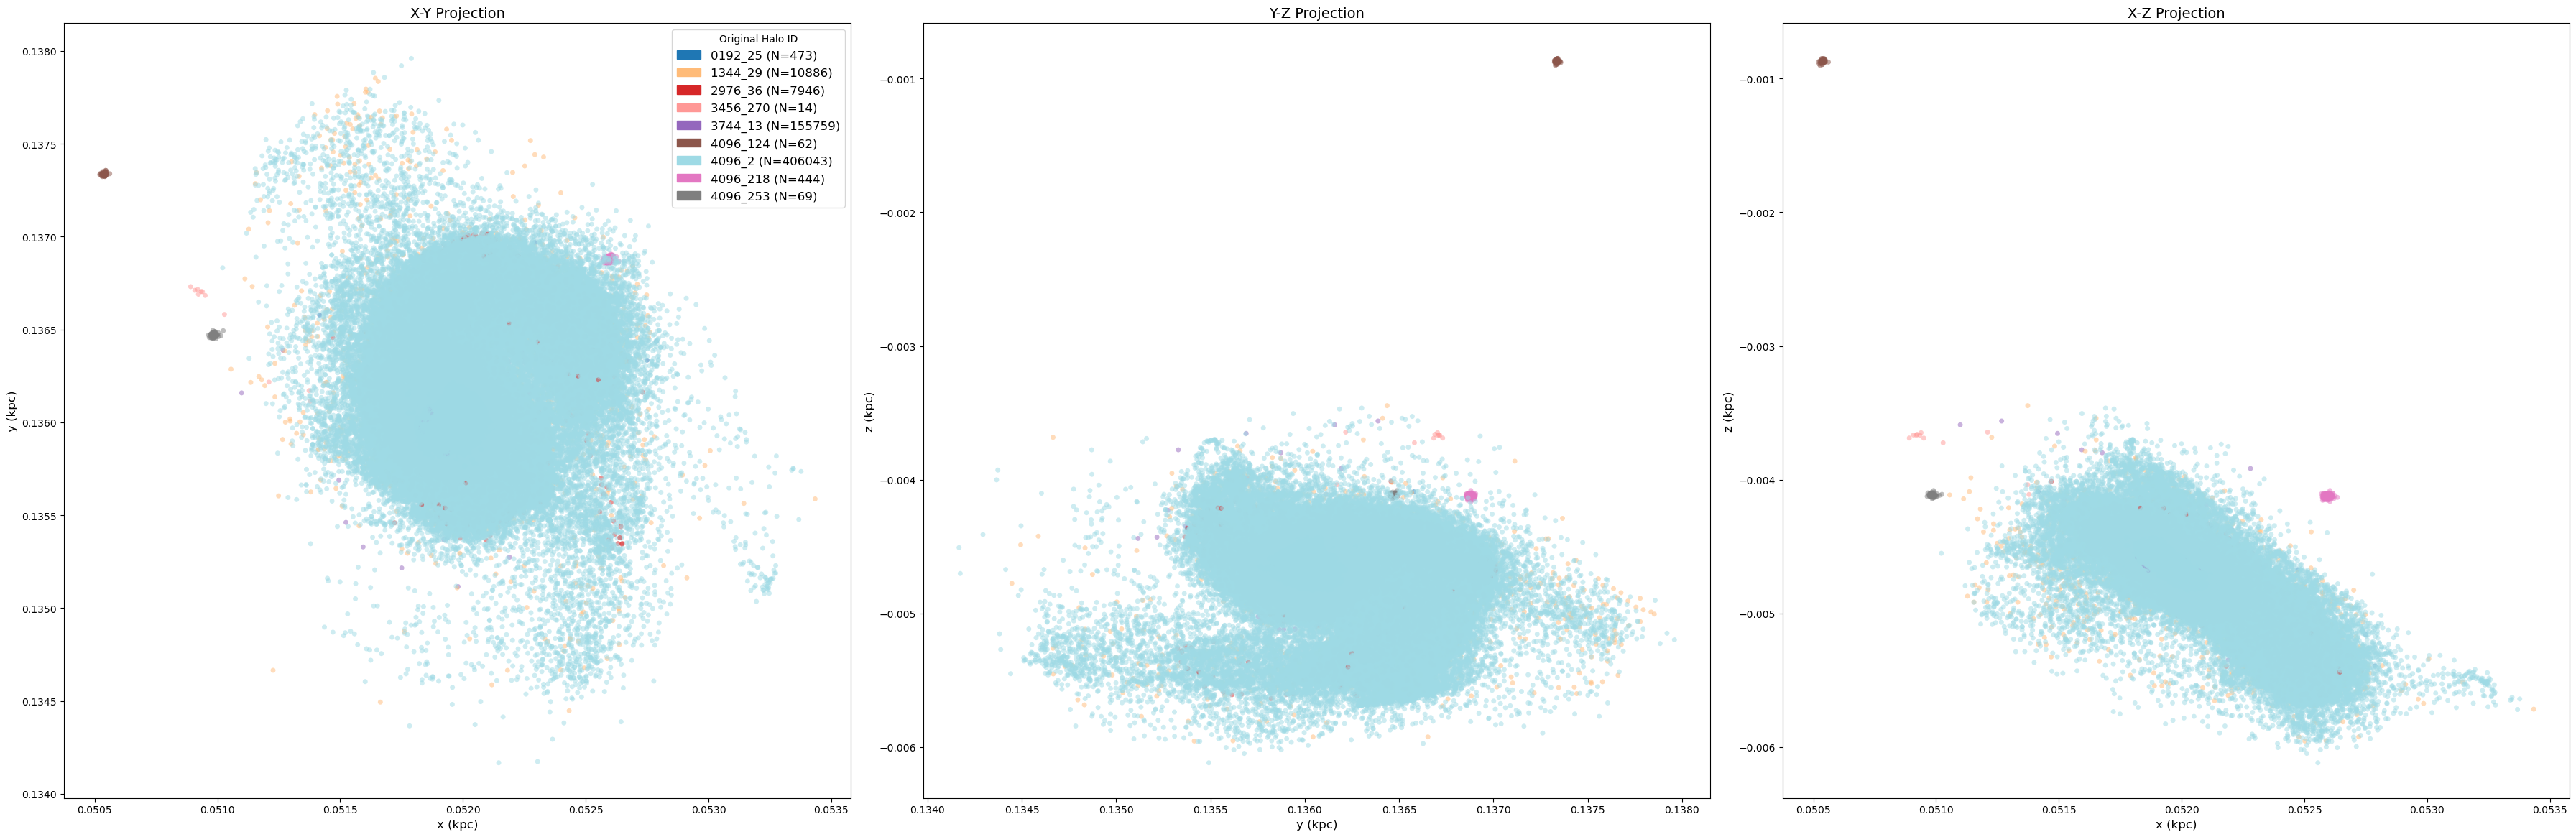

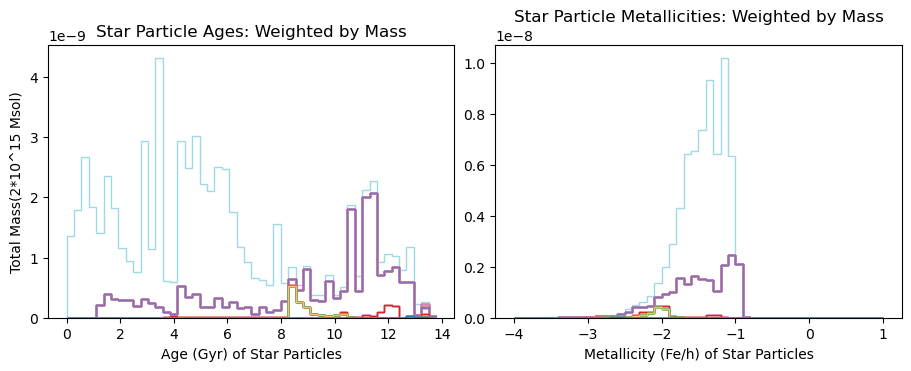

In [15]:
#Sample multiview
multiple_view(["0000_0","0192_25","0288_95","0480_43","0480_61","0576_14","0672_27","0672_9","0864_90","0960_8",
               "1056_27","1056_364","1344_29","1440_49","1632_6","1824_143","2304_133","2304_14","2400_28","2400_29",
               "2688_47","2976_36","3456_270","3456_56","3552_300","3648_85","3648_90","3744_13","4032_287","4096_1",
               "4096_10","4096_11","4096_124","4096_13","4096_14","4096_16","4096_192","4096_20","4096_208",
               "4096_218","4096_22","4096_23","4096_24","4096_253","4096_28","4096_292","4096_3","4096_34","4096_35",
               "4096_39","4096_4","4096_43","4096_47","4096_49","4096_5","4096_50","4096_6","4096_60","4096_7","4096_72",
               "4096_8", "4096_2"], masses = False)

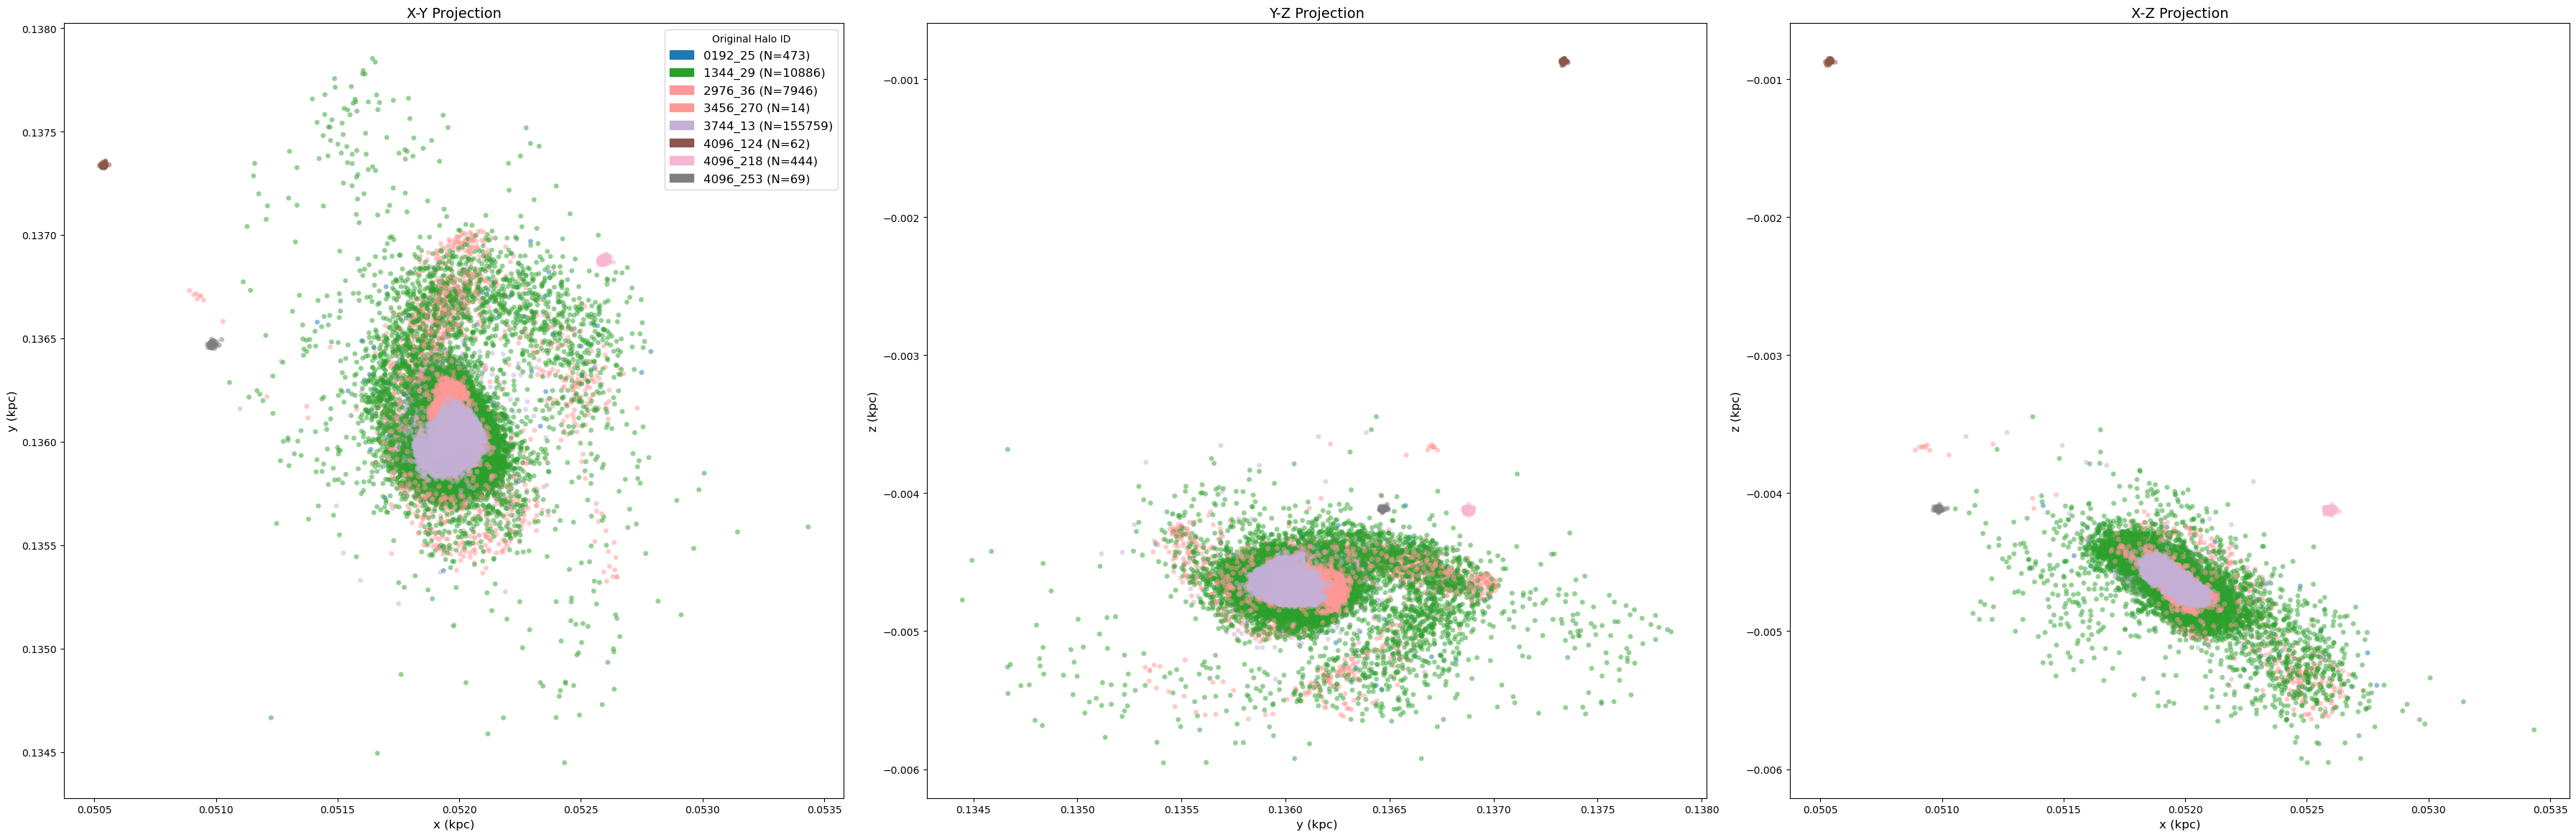

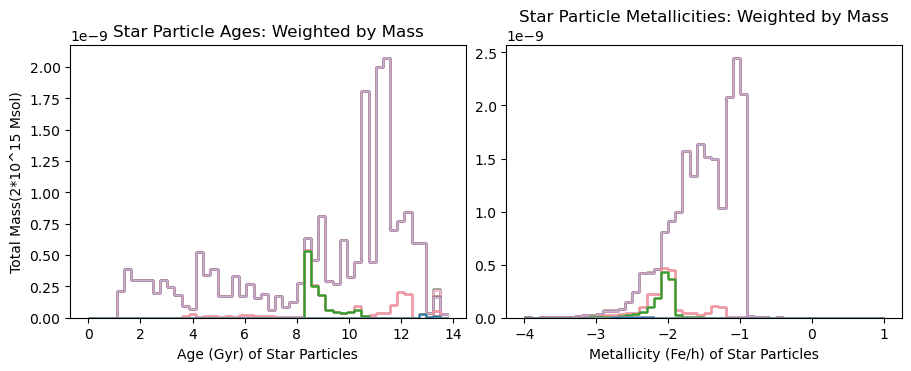

In [16]:
multiple_view(["0000_0","0192_25","0288_95","0480_43","0480_61","0576_14","0672_27","0672_9","0864_90","0960_8",
               "1056_27","1056_364","1344_29","1440_49","1632_6","1824_143","2304_133","2304_14","2400_28","2400_29",
               "2688_47","2976_36","3456_270","3456_56","3552_300","3648_85","3648_90","3744_13","4032_287","4096_1",
               "4096_10","4096_11","4096_124","4096_13","4096_14","4096_16","4096_192","4096_20","4096_208",
               "4096_218","4096_22","4096_23","4096_24","4096_253","4096_28","4096_292","4096_3","4096_34","4096_35",
               "4096_39","4096_4","4096_43","4096_47","4096_49","4096_5","4096_50","4096_6","4096_60","4096_7","4096_72",
               "4096_8"], masses = False)